<a href="https://colab.research.google.com/github/abhinavsuresh121-sys/ML/blob/main/MLE%20and%20MAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

In [3]:
np.random.seed(42)
sns.set_theme(style="whitegrid")

In [4]:
data = load_breast_cancer()

In [5]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [6]:
print("Dataset Shape:", X.shape)
print("Class distribution:", np.bincount(y),
      "(0: Malignant, 1: Benign)")


Dataset Shape: (569, 30)
Class distribution: [212 357] (0: Malignant, 1: Benign)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [8]:
scaler = StandardScaler()

In [9]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
print("Preprocessing complete.")


Preprocessing complete.


In [11]:
mle_model = LogisticRegression(
    penalty=None,
    max_iter=10000
)


In [12]:
mle_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=10000, penalty=None)

In [13]:
map_l2_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=10000
)

In [14]:
map_l2_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=10000)

In [15]:
map_l1_model = LogisticRegression(
    penalty="l1",
    C=1.0,
    solver="saga",
    max_iter=10000
)

In [16]:
map_l1_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=10000, penalty='l1', solver='saga')

In [22]:
def evaluate(model, X, y, name):
    predictions = model.predict(X)
    probabilities = model.predict_proba(X)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y, predictions),
        "Precision": precision_score(y, predictions),
        "Recall": recall_score(y, predictions),
        "F1-Score": f1_score(y, predictions),
        "AUC-ROC": roc_auc_score(y, probabilities)
    }



Parameter Estimates:
                    Feature         MLE  MAP_L2 (Gaussian)  MAP_L1 (Laplace)
0                 Intercept  -63.532600           0.445585          0.299321
1               mean radius    9.433096          -0.431904          0.000000
2              mean texture  -16.986388          -0.387326          0.000000
3            mean perimeter   40.020926          -0.393432          0.000000
4                 mean area   10.890150          -0.465210          0.000000
5           mean smoothness    5.033443          -0.071667          0.000000
6          mean compactness  274.940098           0.540164          0.000000
7            mean concavity -134.838158          -0.801458          0.000000
8       mean concave points -266.184736          -1.119804         -2.195998
9             mean symmetry   40.996505           0.236119          0.053600
10   mean fractal dimension -168.017946           0.075921          0.000000
11             radius error -259.639462          -1.26

In [23]:
# Evaluate all models
results = [
    evaluate(
        mle_model,
        X_test_scaled,
        y_test,
        "MLE (No Regularization)"
    ),
    evaluate(
        map_l2_model,
        X_test_scaled,
        y_test,
        "MAP (L2 Regularization)"
    ),
    evaluate(
        map_l1_model,
        X_test_scaled,
        y_test,
        "MAP (L1 Regularization)"
    )
]


In [24]:

results_df = pd.DataFrame(results)


In [25]:
print("\nPerformance Comparison:")
print(results_df)



Performance Comparison:
                     Model  Accuracy  Precision    Recall  F1-Score   AUC-ROC
0  MLE (No Regularization)  0.938596   0.984848  0.915493  0.948905  0.981330
1  MAP (L2 Regularization)  0.973684   0.972222  0.985915  0.979021  0.997380
2  MAP (L1 Regularization)  0.964912   0.971831  0.971831  0.971831  0.996725


In [26]:
plt.figure(figsize=(15, 6))


<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

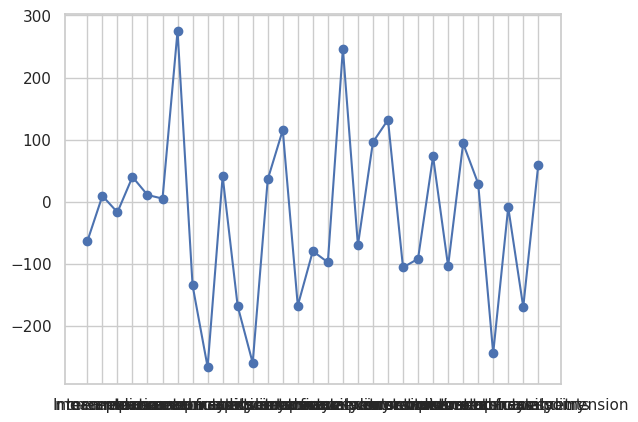

In [27]:
plt.plot(
    weights_df["Feature"],
    weights_df["MLE"],
    marker="o",
    label="MLE"
)


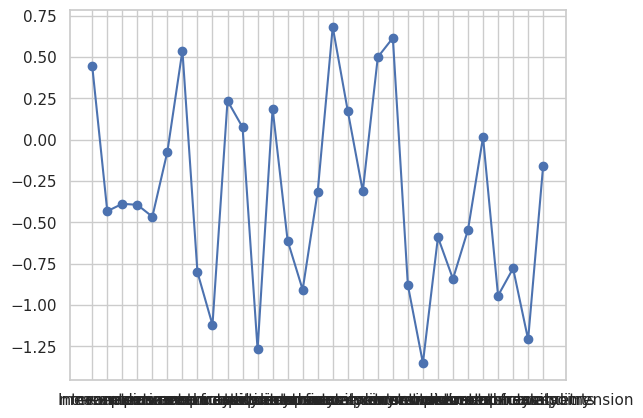

In [28]:
plt.plot(
    weights_df["Feature"],
    weights_df["MAP_L2 (Gaussian)"],
    marker="o",
    label="MAP L2"
)

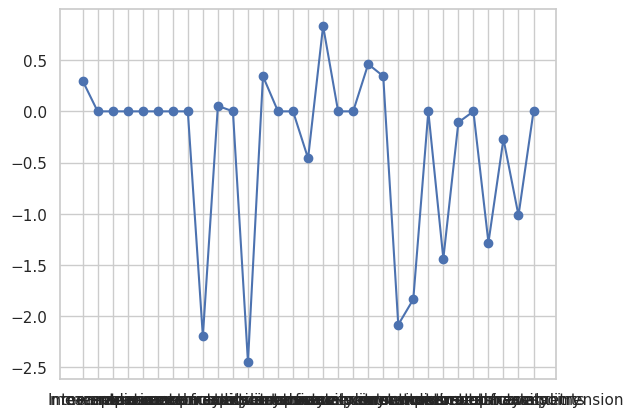

In [29]:
plt.plot(
    weights_df["Feature"],
    weights_df["MAP_L1 (Laplace)"],
    marker="o",
    label="MAP L1"
)

/tmp/ipykernel_659/702409080.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


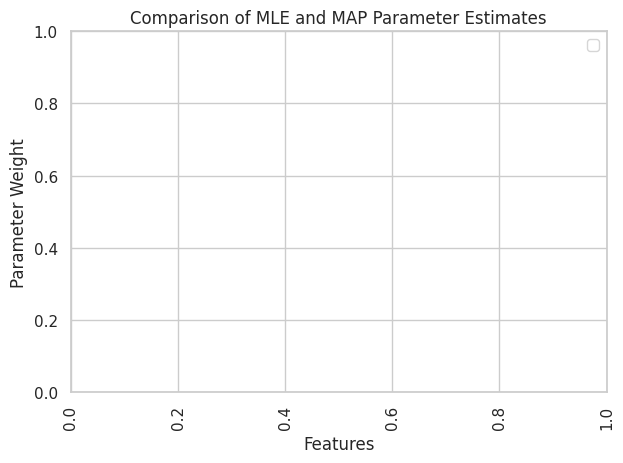

In [30]:
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Parameter Weight")
plt.title("Comparison of MLE and MAP Parameter Estimates")
plt.legend()
plt.tight_layout()
plt.show()


In [31]:
l1_weights = map_l1_model.coef_[0]


In [32]:
zero_weights = np.sum(l1_weights == 0)

In [33]:
print("\nNumber of zero weights in L1 model:", zero_weights)
print("Total number of features:", len(l1_weights))


Number of zero weights in L1 model: 15
Total number of features: 30


In [34]:
results_plot = results_df.set_index("Model")

<Axes: xlabel='Model'>

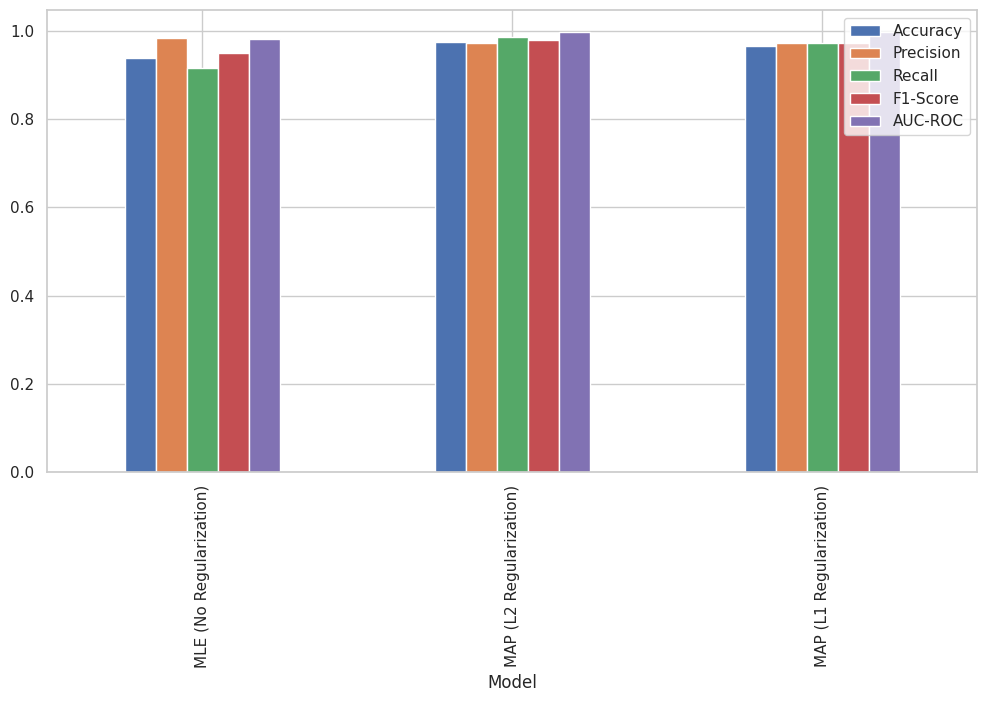

In [35]:
results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)


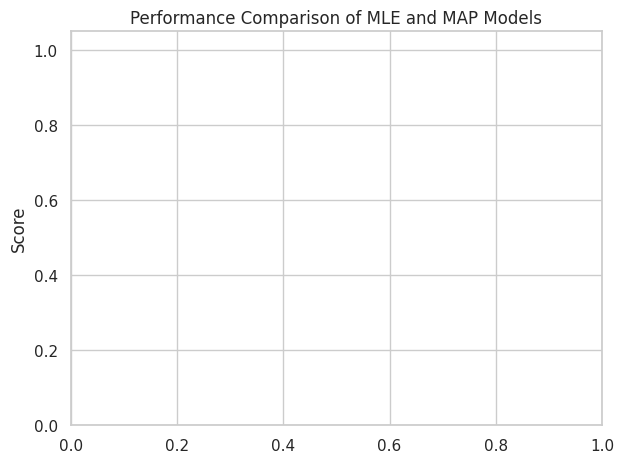

In [36]:
plt.ylabel("Score")
plt.title("Performance Comparison of MLE and MAP Models")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()